# Python Class 7 — Dictionaries & Functions

## Class Goal
In this class, we will build on the dictionary and list concepts from the previous class and then introduce **functions**.

### Topics covered
1. Working with `keys()`, `values()`, and `items()`
2. Understanding `dict_items` and indexing
3. Lists of dictionaries
4. Nested dictionaries
5. Accessing data from nested dictionaries
6. Built-in functions: `print()`, `type()`, and `id()`
7. Creating and calling functions
8. Function parameters and arguments
9. Default parameter values
10. Positional and keyword arguments
11. Introduction to an unknown number of arguments
12. Returning information from functions

> **Important:** Every example below is followed by a line-by-line explanation.

## Part 1 — Dictionary Keys, Values, and Items

A dictionary stores data as **key-value pairs**. Python provides three useful dictionary methods:

- `keys()` → returns the dictionary's keys
- `values()` → returns the dictionary's values
- `items()` → returns key-value pairs together

In [1]:
# A dictionary containing basic personal information.
personal_bio = {
    "first_name": "Saad",
    "last_name": "Ahmed",
    "address": "Karachi, Pakistan"
}

### Line-by-line explanation
- `personal_bio = {` creates a dictionary and stores it in `personal_bio`.
- `"first_name": "Saad"` stores `"Saad"` under the key `"first_name"`.
- `"last_name": "Ahmed"` stores `"Ahmed"` under the key `"last_name"`.
- `"address": "Karachi, Pakistan"` stores the address.
- The closing `}` finishes the dictionary.

In [2]:
# Get all keys from the dictionary.
personal_bio.keys()

dict_keys(['first_name', 'last_name', 'address'])

### Line-by-line explanation
- `personal_bio` refers to our dictionary.
- `.keys()` asks Python for all keys in that dictionary.
- The result is a **view object**, not a normal list.

In [3]:
# Get all values from the dictionary.
personal_bio.values()

dict_values(['Saad', 'Ahmed', 'Karachi, Pakistan'])

### Line-by-line explanation
- `personal_bio` selects the dictionary.
- `.values()` returns a view containing all dictionary values.

In [4]:
# Get all key-value pairs from the dictionary.
personal_bio.items()

dict_items([('first_name', 'Saad'), ('last_name', 'Ahmed'), ('address', 'Karachi, Pakistan')])

### Line-by-line explanation
- `personal_bio` selects the dictionary.
- `.items()` returns a view containing each key-value pair.
- Each pair behaves like a two-item tuple: `(key, value)`.

## Part 2 — Why `items()[0]` Causes an Error

Trying to index `personal_bio.items()` directly, like `personal_bio.items()[0]`, does **not** work because `dict_items` is not a sequence that supports indexing.

In [5]:
# Check the type returned by items().
items_view = personal_bio.items()
print(type(items_view))

<class 'dict_items'>


### Line-by-line explanation
- `items_view = personal_bio.items()` stores the result of `items()` in a variable.
- `type(items_view)` tells us the object's type — it will show `dict_items`, not `list`.
- `print(...)` displays that type on the console.

In [6]:
# Convert the items view into a list so we can use an index.
first_item = list(personal_bio.items())[0]
print(first_item)

# Access the key and value separately.
print("Key:", first_item[0])
print("Value:", first_item[1])

('first_name', 'Saad')
Key: first_name
Value: Saad


### Line-by-line explanation
- `personal_bio.items()` gets all key-value pairs.
- `list(...)` converts those pairs into a list.
- `[0]` selects the first pair.
- `first_item[0]` gets the key from that pair.
- `first_item[1]` gets the value from that pair.
- `print()` displays each result.

## Part 3 — Looping Through Dictionary Items

In [7]:
# Loop through every key-value pair in the dictionary.
for key, value in personal_bio.items():
    print(f"Key: {key}")
    print(f"Value: {value}")
    print("---")

Key: first_name
Value: Saad
---
Key: last_name
Value: Ahmed
---
Key: address
Value: Karachi, Pakistan
---


### Line-by-line explanation
- `for key, value in personal_bio.items():` gets each key-value pair one at a time.
- `key` receives the dictionary key.
- `value` receives the corresponding value.
- `print(f"Key: {key}")` displays the key.
- `print(f"Value: {value}")` displays the value.
- `print("---")` separates one dictionary entry from the next.
- The indented lines belong to the `for` loop.

## Part 4 — Lists of Dictionaries

A **list of dictionaries** is useful when we have multiple records with the same type of information.

In [11]:
# A list containing customer records.
customers = [
    {
        "customer_id": 0,
        "first_name": "Saad",
        "last_name": "Ahmed",
        "address": "North Karachi"
    },
    {
        "customer_id": 1,
        "first_name": "Arfa",
        "last_name": "Zafar",
        "address": "Sargodha"
    },
    {
        "customer_id": 2,
        "first_name": "Haleema",
        "last_name": "Amir",
        "address": "North Karachi"
    }
]

### Line-by-line explanation
- `customers = [` creates a list.
- Each `{ ... }` inside the list is one customer dictionary.
- `customer_id`, `first_name`, `last_name`, and `address` are keys.
- The corresponding text or number after each `:` is its value.
- Commas separate the dictionaries inside the list.

In [12]:
# Get the customer ID from the last dictionary in the list.
print(customers[-1]["customer_id"])

2


### Line-by-line explanation
- `customers[-1]` selects the last dictionary in the list.
- `["customer_id"]` gets the value stored under that key.
- `print()` displays the customer ID.

In [13]:
# Visit each customer and print their complete record and address.
for customer in customers:
    print(customer)
    print("Address:", customer["address"])
    print("---")

{'customer_id': 0, 'first_name': 'Saad', 'last_name': 'Ahmed', 'address': 'North Karachi'}
Address: North Karachi
---
{'customer_id': 1, 'first_name': 'Arfa', 'last_name': 'Zafar', 'address': 'Sargodha'}
Address: Sargodha
---
{'customer_id': 2, 'first_name': 'Haleema', 'last_name': 'Amir', 'address': 'North Karachi'}
Address: North Karachi
---


### Line-by-line explanation
- `for customer in customers:` visits each dictionary in the list.
- `customer` represents the current dictionary.
- `print(customer)` displays the complete dictionary.
- `customer["address"]` retrieves the address from the current dictionary.
- `print("---")` separates the records.

## Part 5 — Appending a New Dictionary to a List of Dictionaries

In [14]:
# Add the existing personal_bio dictionary as a new record.
customers.append(personal_bio)

# Check how many records are now in the list.
print("Total records:", len(customers))

Total records: 4


### Line-by-line explanation
- `customers.append(personal_bio)` adds the `personal_bio` dictionary to the end of `customers`.
- `len(customers)` counts the number of dictionaries in the list.
- `print()` displays the total number of records.

**Important:** `append()` adds the dictionary itself as one new list element.

## Part 6 — Nested Dictionaries

A **nested dictionary** is a dictionary that contains other dictionaries as values. This can be useful when each ID should point to a complete record.

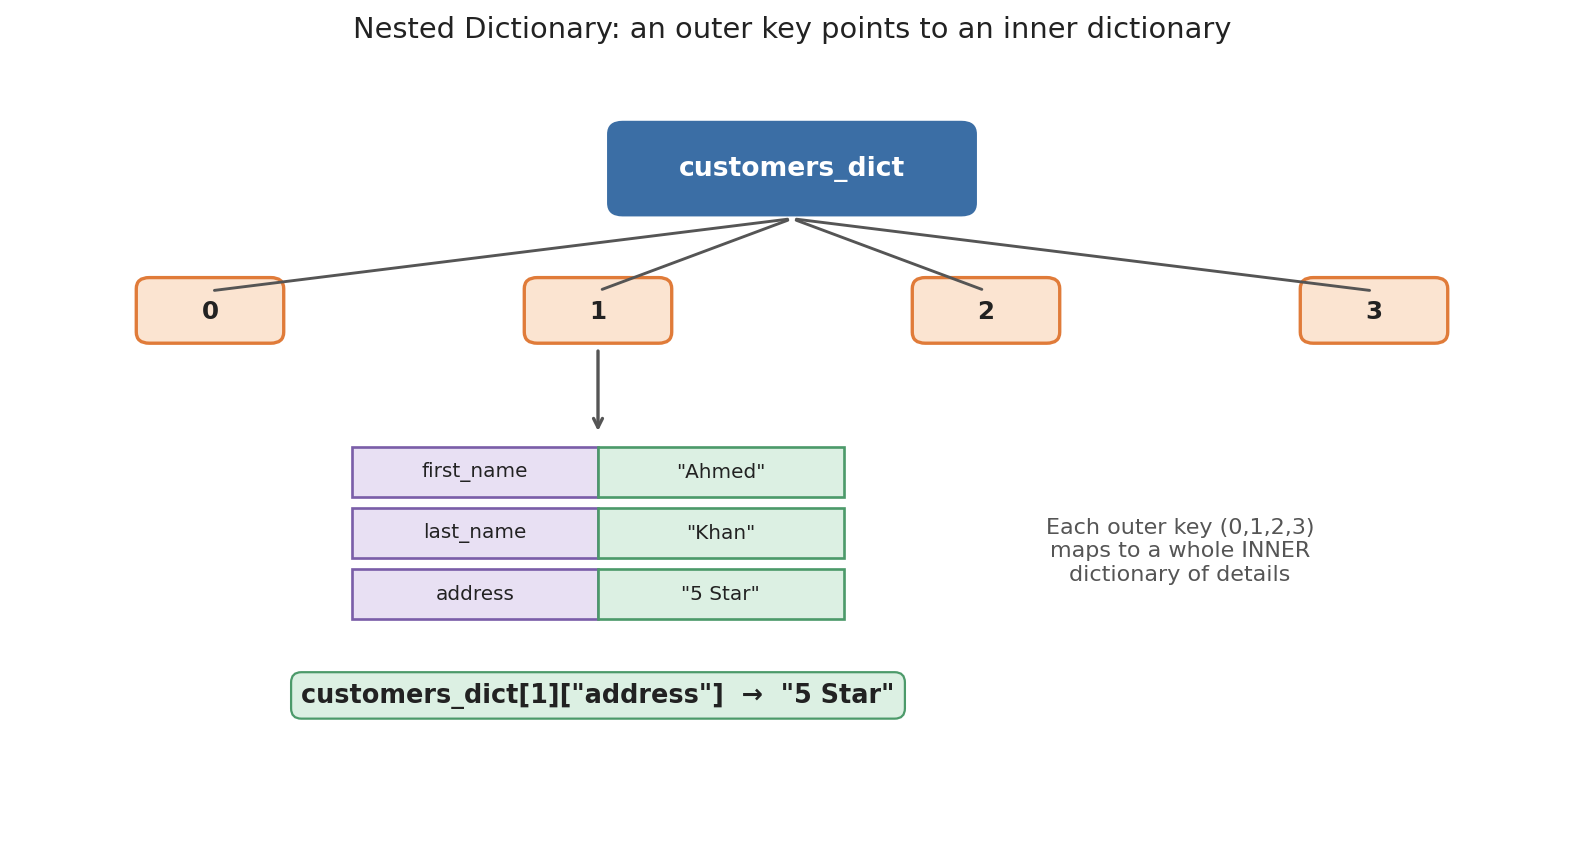

*An outer key points to a whole inner dictionary of details.*

In [16]:
# A dictionary where each customer ID maps to a customer record.
customers_dict = {
    0: {
        "first_name": "Saad",
        "last_name": "Ahmed",
        "address": "North Nazimabad"
    },
    1: {
        "first_name": "Ahmed",
        "last_name": "Khan",
        "address": "5 Star"
    },
    2: {
        "first_name": "Tahami",
        "last_name": "Sheikh",
        "address": "Power House"
    },
    3: {
        "first_name": "Rayyan",
        "last_name": "Asrar",
        "address": "Karachi, Pakistan"
    }
}

### Line-by-line explanation
- `customers_dict = {` creates the outer dictionary.
- `0`, `1`, `2`, and `3` are customer IDs used as outer keys.
- Each ID maps to another dictionary.
- The inner dictionaries contain customer details.
- The final `}` closes the outer dictionary.

## Part 7 — Accessing Data from a Dictionary Inside Another Dictionary

In [17]:
# Loop through the outer dictionary's keys.
for customer_id in customers_dict:
    print("Customer ID:", customer_id)
    print("Address:", customers_dict[customer_id]["address"])
    print("---")

Customer ID: 0
Address: North Nazimabad
---
Customer ID: 1
Address: 5 Star
---
Customer ID: 2
Address: Power House
---
Customer ID: 3
Address: Karachi, Pakistan
---


### Line-by-line explanation
- `for customer_id in customers_dict:` loops through the outer dictionary's keys.
- `customer_id` receives values such as `0`, `1`, `2`, and `3`.
- `customers_dict[customer_id]` selects the inner dictionary.
- `["address"]` selects the address from that inner dictionary.
- `print()` displays the results.

In [18]:
# Loop through the inner dictionaries directly.
for customer in customers_dict.values():
    print(customer)
    print("Address:", customer["address"])
    print("---")

{'first_name': 'Saad', 'last_name': 'Ahmed', 'address': 'North Nazimabad'}
Address: North Nazimabad
---
{'first_name': 'Ahmed', 'last_name': 'Khan', 'address': '5 Star'}
Address: 5 Star
---
{'first_name': 'Tahami', 'last_name': 'Sheikh', 'address': 'Power House'}
Address: Power House
---
{'first_name': 'Rayyan', 'last_name': 'Asrar', 'address': 'Karachi, Pakistan'}
Address: Karachi, Pakistan
---


### Line-by-line explanation
- `customers_dict.values()` returns all inner dictionaries.
- `customer` receives one inner dictionary at a time.
- `print(customer)` displays that dictionary.
- `customer["address"]` retrieves its address.
- The indented statements repeat for every customer.

In [19]:
# Get both the customer ID and the customer record.
for customer_id, customer in customers_dict.items():
    print("Customer ID:", customer_id)
    print("Address:", customer["address"])
    print("---")

Customer ID: 0
Address: North Nazimabad
---
Customer ID: 1
Address: 5 Star
---
Customer ID: 2
Address: Power House
---
Customer ID: 3
Address: Karachi, Pakistan
---


### Line-by-line explanation
- `.items()` returns each outer key and value together.
- `customer_id` receives the outer key.
- `customer` receives the inner dictionary.
- `customer["address"]` retrieves the address from that inner dictionary.
- This is usually the clearest approach when you need both the ID and the record.

In [20]:
# Since the outer keys are 0, 1, 2, and 3, they can be used to access records.
for customer_id in range(len(customers_dict)):
    print(customers_dict[customer_id]["address"])

North Nazimabad
5 Star
Power House
Karachi, Pakistan


### Line-by-line explanation
- `len(customers_dict)` gives the number of records.
- `range(...)` produces numbers from `0` up to one less than that count.
- `customer_id` receives each number.
- `customers_dict[customer_id]` selects the matching inner dictionary.
- `["address"]` retrieves its address.
- This example works because the keys are consecutive integers starting at `0`. In general, looping with `.items()` is safer when dictionary keys are not guaranteed to have that pattern.

## Part 8 — Another Nested Dictionary Example

In [21]:
# Course information stored inside a nested dictionary.
courses = {
    "Python": {
        "timings": "Monday",
        "instructor": "Saad"
    },
    "Cloud Data Engineering": {
        "timings": "Sunday",
        "instructor": "Saad"
    }
}

### Line-by-line explanation
- `courses = {` creates the outer dictionary.
- `"Python"` and `"Cloud Data Engineering"` are course names.
- Each course name maps to an inner dictionary.
- The inner dictionary stores the course timing and instructor.

In [22]:
# Display each course and its instructor.
for course_name, course_info in courses.items():
    print("Course:", course_name)
    print("Instructor:", course_info["instructor"])
    print("---")

Course: Python
Instructor: Saad
---
Course: Cloud Data Engineering
Instructor: Saad
---


### Line-by-line explanation
- `.items()` gives the course name and its inner dictionary.
- `course_name` stores the outer key.
- `course_info` stores the inner dictionary.
- `course_info["instructor"]` retrieves the instructor.
- The loop repeats for every course.

## Part 9 — Functions

A **function** is a reusable block of code that performs a specific task.

### Common built-in functions
- `print()` displays information.
- `type()` tells us the type of a value or object.
- `id()` returns an identity value associated with an object during its lifetime.

### Why use functions?
- **Reusability:** write code once and use it many times.
- **Modularity:** break a large program into smaller, understandable parts.
- **Maintainability:** changes are easier when logic is organized into functions.

Basic idea:

**Input → Function → Result**

## Part 10 — Creating and Calling a Function

In [28]:
# Define a function that prints a course message.
def print_course_message():
    print("Free Python course by Saad")

### Line-by-line explanation
- `def` tells Python that we are defining a function.
- `print_course_message` is the function name.
- `()` means this function does not need any arguments.
- `:` starts the function body.
- The indented `print()` statement runs when the function is called.

In [29]:
# Call the function.
print_course_message()

Free Python course by Saad


### Line-by-line explanation
- `print_course_message()` calls the function.
- Python enters the function body and executes its `print()` statement.
- We can call the same function again whenever we need it.

In [30]:
# The same function can be called multiple times.
print_course_message()
print_course_message()

Free Python course by Saad
Free Python course by Saad


### Line-by-line explanation
- The first line calls the function once.
- The second line calls it again.
- The function's code does not need to be rewritten.

## Part 11 — Function with Parameters

A function becomes more reusable when we pass information into it through **parameters**.

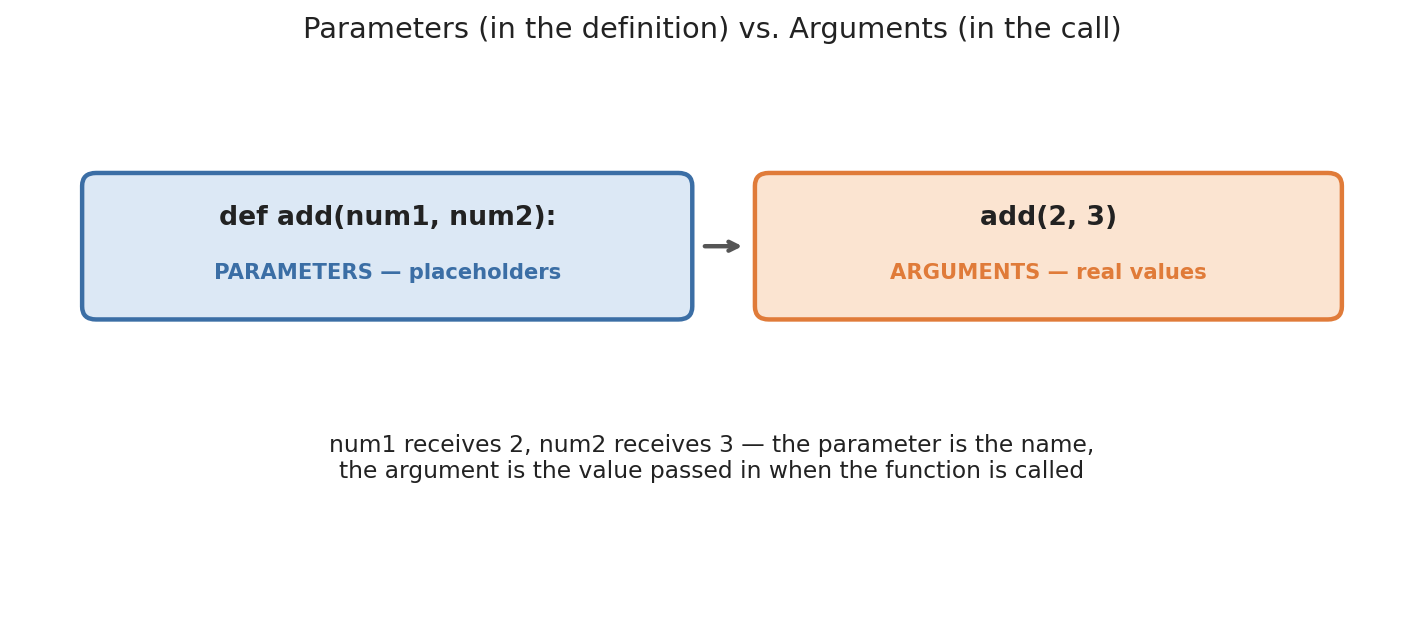

*Parameters are placeholders in the definition; arguments are the real values passed in.*

In [31]:
# Define a function that adds two numbers.
def add(num1, num2):
    print(num1 + num2)

### Line-by-line explanation
- `def` starts the function definition.
- `add` is the function name.
- `num1` and `num2` are **parameters**.
- The function receives two values and adds them.
- `print(num1 + num2)` displays the result.

In [32]:
# Pass two arguments to the function.
add(2, 3)
add(6, 7)

5
13


### Line-by-line explanation
- `add(2, 3)` sends `2` to `num1` and `3` to `num2`.
- `add(6, 7)` sends `6` to `num1` and `7` to `num2`.
- The function can therefore work with different values.

### What happens if an argument is missing?

In [33]:
# This intentionally raises a TypeError because num2 was not provided.
# Uncomment the next line to see the error.
# add(6)

### Explanation
`add()` requires two arguments because the function definition has two required parameters: `num1` and `num2`.

Calling `add(6)` provides only one argument, so Python raises a `TypeError`.

**Parameter vs argument**
- **Parameter:** the variable written in the function definition, such as `num1`.
- **Argument:** the actual value passed during the function call, such as `6`.

## Part 12 — Default Parameter Values

In [34]:
# Use a default value for the Kelvin conversion offset.
def celsius_to_kelvin(celsius, kelvin_offset=273.15):
    print(celsius + kelvin_offset)

### Line-by-line explanation
- `celsius` is a required parameter.
- `kelvin_offset=273.15` gives the second parameter a default value.
- If the caller does not provide `kelvin_offset`, Python uses `273.15`.
- The function adds Celsius to the offset and prints the result.

In [35]:
# Use the default offset.
celsius_to_kelvin(45)

# Provide a custom offset.
celsius_to_kelvin(45, 273)

318.15
318


### Line-by-line explanation
- `celsius_to_kelvin(45)` supplies only `celsius`, so the default `273.15` is used.
- `celsius_to_kelvin(45, 273)` supplies both arguments, so `273` replaces the default value.

## Part 13 — Positional and Keyword Arguments

In [36]:
# Define a greeting function with a default greeting.
def greeting(first_name, last_name, message="Welcome"):
    print(f"Hey, {first_name} {last_name}, {message}")

### Line-by-line explanation
- `first_name` is the first required parameter.
- `last_name` is the second required parameter.
- `message="Welcome"` is an optional parameter with a default value.
- The f-string inserts the parameter values into the sentence.
- `print()` displays the final greeting.

In [37]:
# Positional arguments are matched by their position.
greeting("Saad", "Ahmed")

Hey, Saad Ahmed, Welcome


### Line-by-line explanation
- `"Saad"` goes to `first_name`.
- `"Ahmed"` goes to `last_name`.
- No `message` is provided, so `"Welcome"` is used.

In [38]:
# Changing the order of positional arguments changes their meaning.
greeting("Ahmed", "Saad")

Hey, Ahmed Saad, Welcome


### Line-by-line explanation
- `"Ahmed"` is placed in `first_name`.
- `"Saad"` is placed in `last_name`.
- Python follows the order of positional arguments; it does not know which name you intended.

In [39]:
# Keyword arguments identify parameters by name.
greeting(first_name="Saad", last_name="Ahmed")

Hey, Saad Ahmed, Welcome


### Line-by-line explanation
- `first_name="Saad"` explicitly assigns `"Saad"` to `first_name`.
- `last_name="Ahmed"` explicitly assigns `"Ahmed"` to `last_name`.
- Because the parameter names are written, their order can be changed.

In [40]:
# Keyword arguments can be written in a different order.
greeting(last_name="Ahmed", first_name="Saad")

Hey, Saad Ahmed, Welcome


### Line-by-line explanation
- `last_name="Ahmed"` assigns the value directly to `last_name`.
- `first_name="Saad"` assigns the value directly to `first_name`.
- Python matches keyword arguments by parameter name rather than position.

## Part 14 — Introduction to an Unknown Number of Arguments

Sometimes we do not know in advance how many values a function will receive. Python supports this with special parameter syntax such as `*args` and `**kwargs`.

In [41]:
# *args collects any number of positional arguments into a tuple.
def show_numbers(*numbers):
    print("Numbers:", numbers)

show_numbers(10, 20, 30)

Numbers: (10, 20, 30)


### Line-by-line explanation
- `*numbers` allows the function to receive any number of positional arguments.
- Inside the function, `numbers` is a tuple containing those arguments.
- `print()` displays the tuple.
- `show_numbers(10, 20, 30)` passes three values to the function.

In [42]:
# **kwargs collects keyword arguments into a dictionary.
def show_details(**details):
    print("Details:", details)

show_details(name="Saad", course="Python")

Details: {'name': 'Saad', 'course': 'Python'}


### Line-by-line explanation
- `**details` collects keyword arguments.
- Inside the function, `details` is a dictionary.
- `name="Saad"` and `course="Python"` become key-value pairs.
- `show_details(...)` calls the function with those keyword arguments.

## Part 15 — Returning Information from a Function

`print()` displays a result. `return` sends a result back to the place where the function was called, allowing us to store or use it later.

In [43]:
# Return the sum instead of printing it directly.
def add_numbers(num1, num2):
    return num1 + num2

result = add_numbers(10, 5)
print("Result:", result)

Result: 15


### Line-by-line explanation
- `def add_numbers(num1, num2):` defines a function with two parameters.
- `return num1 + num2` calculates the sum and sends it back to the caller.
- `result = add_numbers(10, 5)` calls the function and stores the returned value in `result`.
- `print("Result:", result)` displays the stored result.

### Key difference
- `print()` → shows something on the screen.
- `return` → sends a value back so the program can use it.

## Practice Questions

### Dictionary practice

1. Create a dictionary containing your name, city, and favorite subject. Use `keys()`, `values()`, and `items()` on it.

2. Why can't `my_dict.items()[0]` be used directly? Explain what `items()` returns.

3. Convert a dictionary's items into a list and access the first key-value pair.

4. Write a `for` loop that prints every key and value separately.

5. Explain the difference between a dictionary key, value, and item.

### Lists of dictionaries practice

1. Create a list containing three student dictionaries.

2. Access the last student's name using a negative index.

3. Loop through the list and print every student's name.

4. Add a new student dictionary using `append()`.

5. Count how many student records are in the list using `len()`.

### Nested dictionaries practice

1. Create a nested dictionary containing two courses and their instructors.

2. Access the instructor of one course.

3. Loop through the nested dictionary using `.items()`.

4. Explain the difference between accessing a value through an outer key and through an inner dictionary.

5. Create a nested dictionary for three products containing price and quantity.

### Functions practice

1. Create a function that prints a short welcome message and call it twice.

2. Create a function that accepts two numbers and prints their product.

3. Create a function with one required parameter and one default parameter.

4. Write one function call using positional arguments and another using keyword arguments.

5. Create a function that returns a calculated value, store that returned value in a variable, and print it.

# Class 7 — Final Review

Before moving to the next class, make sure you can explain:

- `keys()`, `values()`, and `items()`
- Why `dict_items` cannot be indexed directly
- How to convert dictionary items to a list
- How to loop through dictionaries
- Lists of dictionaries
- Nested dictionaries
- How to access values inside nested dictionaries
- What a function is
- How to define and call a function
- Parameters vs arguments
- Default parameter values
- Positional vs keyword arguments
- `*args` and `**kwargs`
- `print()` vs `return`

## Mini Challenge

Create a small **student management example** using:
1. A list of dictionaries for several students.
2. A function that prints one student's information.
3. A function that returns a student's name.
4. A nested dictionary for course information.

**Do not look at the examples above while solving it if you want to test yourself.**

---

## 👨‍💻 About This Course

This **free Python course** was designed and developed by **Muhammad Saad** as a contribution toward making programming education more accessible. I created it to share what I’ve learned with students and beginners who want to learn Python but may not have access to paid courses.

The goal is simple: **to make learning Python easier, accessible, and beginner-friendly.** If this course helps someone learn a new skill or take their first step into programming, then this initiative has achieved its purpose.

If you found this class helpful, feel free to share it with someone who might benefit from it.